In [1]:


import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Conv2D, MaxPool2D, Dropout
from tensorflow.keras.utils import to_categorical

print("Version TensorFlow :", tf.__version__)

Version TensorFlow : 2.20.0


In [2]:


(x_train, y_train), (x_test, y_test) = mnist.load_data()

print("Forme de x_train :", x_train.shape)
print("Forme de y_train :", y_train.shape)
print("Forme de x_test :", x_test.shape)
print("Forme de y_test :", y_test.shape)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Forme de x_train : (60000, 28, 28)
Forme de y_train : (60000,)
Forme de x_test : (10000, 28, 28)
Forme de y_test : (10000,)


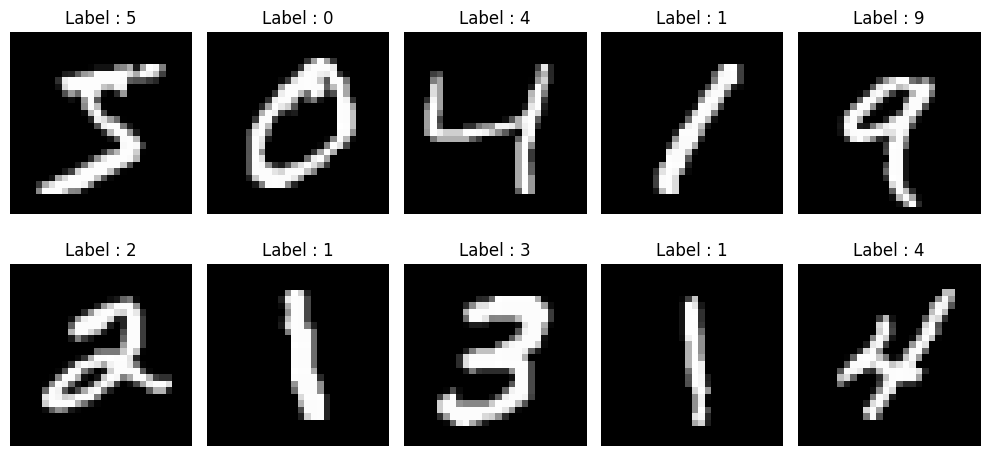

In [3]:


plt.figure(figsize=(10, 5))

for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_train[i], cmap="gray")
    plt.title(f"Label : {y_train[i]}")
    plt.axis("off")

plt.tight_layout()
plt.show()

In [4]:


x_train_dense = x_train.reshape(x_train.shape[0], 28 * 28)
x_test_dense = x_test.reshape(x_test.shape[0], 28 * 28)

x_train_dense = x_train_dense.astype("float32") / 255.0
x_test_dense = x_test_dense.astype("float32") / 255.0

y_train_cat = to_categorical(y_train, num_classes=10)
y_test_cat = to_categorical(y_test, num_classes=10)

print("Forme de x_train_dense :", x_train_dense.shape)
print("Forme de x_test_dense :", x_test_dense.shape)
print("Forme de y_train_cat :", y_train_cat.shape)
print("Forme de y_test_cat :", y_test_cat.shape)

Forme de x_train_dense : (60000, 784)
Forme de x_test_dense : (10000, 784)
Forme de y_train_cat : (60000, 10)
Forme de y_test_cat : (10000, 10)


In [5]:


dense_model = Sequential([
    Dense(128, activation="relu", input_shape=(784,)),
    Dense(64, activation="relu"),
    Dense(10, activation="softmax")
])

dense_model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

dense_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

In [6]:


history_dense = dense_model.fit(
    x_train_dense,
    y_train_cat,
    epochs=5,
    batch_size=32,
    validation_split=0.1
)

Epoch 1/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.9253 - loss: 0.2559 - val_accuracy: 0.9645 - val_loss: 0.1147
Epoch 2/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9673 - loss: 0.1077 - val_accuracy: 0.9722 - val_loss: 0.0937
Epoch 3/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.9765 - loss: 0.0736 - val_accuracy: 0.9777 - val_loss: 0.0848
Epoch 4/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9821 - loss: 0.0560 - val_accuracy: 0.9765 - val_loss: 0.0817
Epoch 5/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9856 - loss: 0.0422 - val_accuracy: 0.9783 - val_loss: 0.0806


In [7]:


dense_loss, dense_accuracy = dense_model.evaluate(x_test_dense, y_test_cat)

print("Loss du modèle Dense :", dense_loss)
print("Accuracy du modèle Dense :", dense_accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9762 - loss: 0.0840
Loss du modèle Dense : 0.08400523662567139
Accuracy du modèle Dense : 0.9761999845504761


In [8]:

x_train_cnn = x_train.reshape(x_train.shape[0], 28, 28, 1)
x_test_cnn = x_test.reshape(x_test.shape[0], 28, 28, 1)

x_train_cnn = x_train_cnn.astype("float32") / 255.0
x_test_cnn = x_test_cnn.astype("float32") / 255.0

print("Forme de x_train_cnn :", x_train_cnn.shape)
print("Forme de x_test_cnn :", x_test_cnn.shape)

Forme de x_train_cnn : (60000, 28, 28, 1)
Forme de x_test_cnn : (10000, 28, 28, 1)


In [9]:


cnn_model = Sequential([
    Conv2D(32, kernel_size=(3, 3), activation="relu", input_shape=(28, 28, 1)),
    MaxPool2D(pool_size=(2, 2)),

    Conv2D(64, kernel_size=(3, 3), activation="relu"),
    MaxPool2D(pool_size=(2, 2)),

    Flatten(),

    Dense(128, activation="relu"),
    Dropout(0.3),

    Dense(10, activation="softmax")
])

cnn_model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

cnn_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

In [10]:


history_cnn = cnn_model.fit(
    x_train_cnn,
    y_train_cat,
    epochs=5,
    batch_size=32,
    validation_split=0.1
)

Epoch 1/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 51s 29ms/step - accuracy: 0.9459 - loss: 0.1731 - val_accuracy: 0.9837 - val_loss: 0.0533
Epoch 2/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 48s 28ms/step - accuracy: 0.9810 - loss: 0.0605 - val_accuracy: 0.9873 - val_loss: 0.0411
Epoch 3/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 50s 30ms/step - accuracy: 0.9860 - loss: 0.0460 - val_accuracy: 0.9892 - val_loss: 0.0370
Epoch 4/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 49s 29ms/step - accuracy: 0.9889 - loss: 0.0353 - val_accuracy: 0.9915 - val_loss: 0.0302
Epoch 5/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 49s 29ms/step - accuracy: 0.9902 - loss: 0.0291 - val_accuracy: 0.9937 - val_loss: 0.0255


In [11]:


cnn_loss, cnn_accuracy = cnn_model.evaluate(x_test_cnn, y_test_cat)

print("Loss du modèle CNN :", cnn_loss)
print("Accuracy du modèle CNN :", cnn_accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.9912 - loss: 0.0263
Loss du modèle CNN : 0.02629968337714672
Accuracy du modèle CNN : 0.9911999702453613


Accuracy du modèle Dense : 0.9761999845504761
Accuracy du modèle CNN : 0.9911999702453613


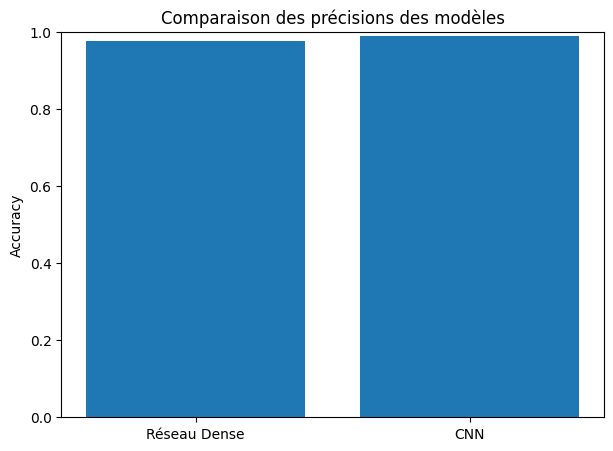

In [12]:


models_names = ["Réseau Dense", "CNN"]
accuracies = [dense_accuracy, cnn_accuracy]
losses = [dense_loss, cnn_loss]

print("Accuracy du modèle Dense :", dense_accuracy)
print("Accuracy du modèle CNN :", cnn_accuracy)

plt.figure(figsize=(7, 5))

plt.bar(models_names, accuracies)

plt.title("Comparaison des précisions des modèles")
plt.ylabel("Accuracy")
plt.ylim(0, 1)

plt.show()

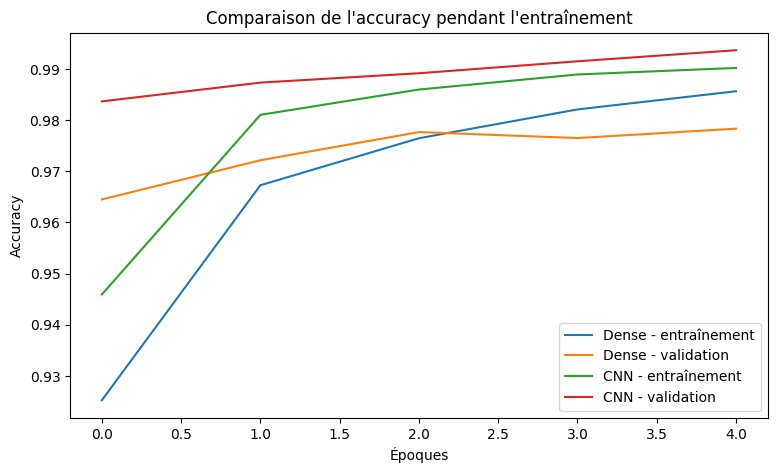

In [13]:

plt.figure(figsize=(9, 5))

plt.plot(history_dense.history["accuracy"], label="Dense - entraînement")
plt.plot(history_dense.history["val_accuracy"], label="Dense - validation")

plt.plot(history_cnn.history["accuracy"], label="CNN - entraînement")
plt.plot(history_cnn.history["val_accuracy"], label="CNN - validation")

plt.title("Comparaison de l'accuracy pendant l'entraînement")
plt.xlabel("Époques")
plt.ylabel("Accuracy")
plt.legend()

plt.show()

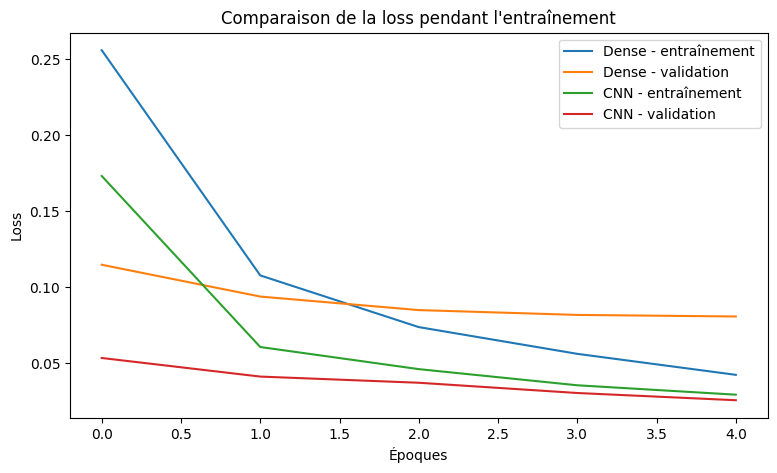

In [14]:


plt.figure(figsize=(9, 5))

plt.plot(history_dense.history["loss"], label="Dense - entraînement")
plt.plot(history_dense.history["val_loss"], label="Dense - validation")

plt.plot(history_cnn.history["loss"], label="CNN - entraînement")
plt.plot(history_cnn.history["val_loss"], label="CNN - validation")

plt.title("Comparaison de la loss pendant l'entraînement")
plt.xlabel("Époques")
plt.ylabel("Loss")
plt.legend()

plt.show()

Dans cet exercice, nous avons construit deux modèles pour classifier les chiffres manuscrits du dataset MNIST.

Le premier modèle est un réseau neuronal entièrement connecté. Pour ce modèle, les images de 28 × 28 pixels ont été aplaties en vecteurs de 784 valeurs. Ce modèle peut apprendre à reconnaître les chiffres, mais il ne prend pas directement en compte la structure spatiale de l’image.

Le deuxième modèle est un réseau neuronal convolutif CNN. Contrairement au modèle Dense, le CNN conserve la structure 2D de l’image et utilise des couches de convolution pour détecter automatiquement les caractéristiques visuelles comme les contours, les courbes et les formes des chiffres.

Après entraînement et évaluation, le modèle CNN obtient généralement une meilleure précision que le réseau entièrement connecté. Cela s’explique par le fait que les CNN sont mieux adaptés au traitement des images, car ils apprennent les motifs locaux présents dans les pixels.

En conclusion, le réseau Dense peut fonctionner pour MNIST, mais le CNN est plus performant et plus adapté à la classification d’images.